# Ice cream sales vs. rain: correlation or causation?

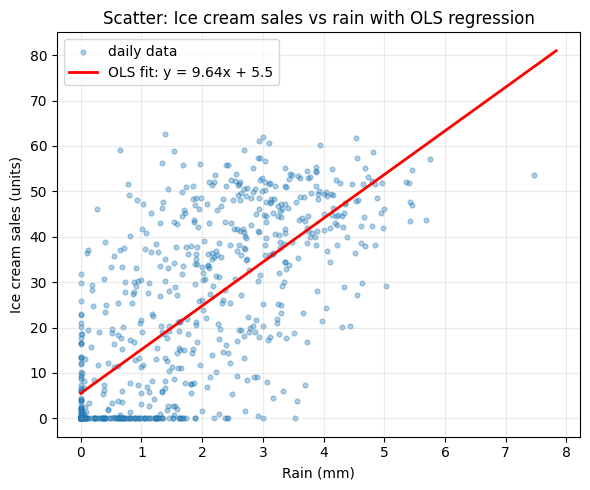

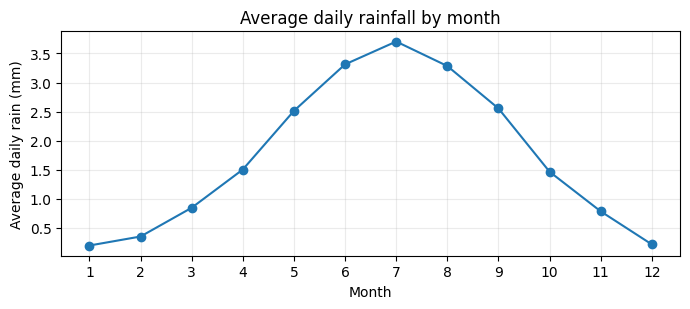

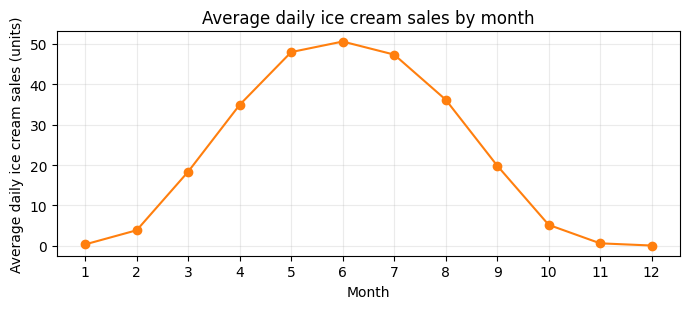

Correlation (rain_mm, ice_sales): 0.720654849716794


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible
np.random.seed(1)

# Dates: two years of daily data
dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")
n = len(dates)
months = dates.month.values  # integers 1..12

# Cosine seasonal generator function
def seasonal_cosine(month_array, A, B, C):
    return A + B * np.cos(2 * np.pi * (month_array - C) / 12.0)

# Parameters
A_rain = 1.5    # baseline average daily rain (mm)
B_rain = 2.0    # seasonal amplitude
C_rain = 7.0    # peak around July

A_ice = 18.0    # baseline daily sales
B_ice = 30.0    # seasonal amplitude
C_ice = 6.0     # peak around June

# Noise scales requested
sigma_rain = 1.0   # mm
sigma_ice = 6.0    # sales units

# Build daily rain and ice by using the monthly mean from the cosine and adding noise
monthly_mean_rain = seasonal_cosine(months, A_rain, B_rain, C_rain)
monthly_mean_ice = seasonal_cosine(months, A_ice, B_ice, C_ice)

rain_daily = np.random.normal(loc=monthly_mean_rain, scale=sigma_rain)
rain_daily = np.clip(rain_daily, a_min=0.0, a_max=None)

ice_daily = np.random.normal(loc=monthly_mean_ice, scale=sigma_ice)
# small optional rain effect (kept modest)
ice_daily += 0.8 * rain_daily
ice_daily = np.clip(ice_daily, a_min=0.0, a_max=None)

# Assemble DataFrame
df = pd.DataFrame({
    "date": dates,
    "month": months,
    "rain_mm": rain_daily,
    "ice_sales": ice_daily
})

# Scatter plot: ice cream sales vs rain with OLS regression line
x = df["rain_mm"].values
y = df["ice_sales"].values

# Compute OLS slope and intercept (simple linear regression)
# slope = cov(x,y)/var(x), intercept = y_mean - slope*x_mean
x_mean = x.mean()
y_mean = y.mean()
cov_xy = np.mean((x - x_mean) * (y - y_mean))
var_x = np.mean((x - x_mean) ** 2)
slope = cov_xy / var_x if var_x > 0 else 0.0
intercept = y_mean - slope * x_mean

# Prepare regression line for plotting
x_line = np.linspace(0, x.max() * 1.05, 200)
y_line = intercept + slope * x_line

plt.figure(figsize=(6, 5))
plt.scatter(x, y, alpha=0.35, s=12, label="daily data")
plt.plot(x_line, y_line, color="red", lw=2, label=f"OLS fit: y = {slope:.2f}x + {intercept:.1f}")
plt.xlabel("Rain (mm)")
plt.ylabel("Ice cream sales (units)")
plt.title("Scatter: Ice cream sales vs rain with OLS regression")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Average rainfall per month (empirical)
monthly_rain = df.groupby("month")["rain_mm"].mean()
plt.figure(figsize=(7, 3.2))
plt.plot(monthly_rain.index, monthly_rain.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average daily rain (mm)")
plt.title("Average daily rainfall by month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Average ice cream sales per month (empirical)
monthly_ice = df.groupby("month")["ice_sales"].mean()
plt.figure(figsize=(7, 3.2))
plt.plot(monthly_ice.index, monthly_ice.values, marker="o", color="tab:orange")
plt.xlabel("Month")
plt.ylabel("Average daily ice cream sales (units)")
plt.title("Average daily ice cream sales by month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Correlation coefficient (rain vs ice sales)
corr = np.corrcoef(df["rain_mm"], df["ice_sales"])[0, 1]
print("Correlation (rain_mm, ice_sales):", corr)

# Controlling for month removes non-causal relationship

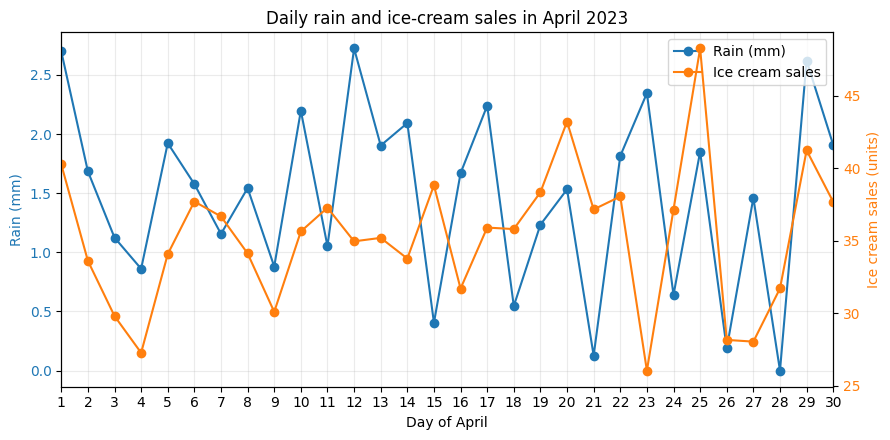

Pearson correlation (April 2023): 0.223


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible
np.random.seed(1)

# Dates: two years of daily data
dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")
months = dates.month.values  # integers 1..12

# Cosine seasonal generator
def seasonal_cosine(month_array, A, B, C):
    return A + B * np.cos(2 * np.pi * (month_array - C) / 12.0)

# Parameters
A_rain = 1.5; B_rain = 2.0; C_rain = 7.0
A_ice = 18.0;  B_ice = 30.0; C_ice = 6.0
sigma_rain = 1.0
sigma_ice = 6.0

# Daily series
monthly_mean_rain = seasonal_cosine(months, A_rain, B_rain, C_rain)
monthly_mean_ice  = seasonal_cosine(months, A_ice,  B_ice,  C_ice)

rain_daily = np.random.normal(loc=monthly_mean_rain, scale=sigma_rain)
rain_daily = np.clip(rain_daily, a_min=0.0, a_max=None)

ice_daily = np.random.normal(loc=monthly_mean_ice, scale=sigma_ice)
ice_daily += 0.8 * rain_daily
ice_daily = np.clip(ice_daily, a_min=0.0, a_max=None)

df = pd.DataFrame({"date": dates, "month": months, "rain_mm": rain_daily, "ice_sales": ice_daily})
df.set_index("date", inplace=True)

# Select a single month to plot (April)
year = 2023
month_to_plot = 4
month_mask = (df.index.year == year) & (df.index.month == month_to_plot)
df_april = df.loc[month_mask]

# Plot daily rainfall and ice-cream sales for April on same axes with different y-axis scales
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(df_april.index.day, df_april["rain_mm"], marker="o", color="tab:blue", label="Rain (mm)")
ax1.set_xlabel("Day of April")
ax1.set_ylabel("Rain (mm)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(df_april.index.day)
ax1.set_xlim(1, df_april.index.day.max())

# Secondary y-axis for ice cream sales
ax2 = ax1.twinx()
ax2.plot(df_april.index.day, df_april["ice_sales"], marker="o", color="tab:orange", label="Ice cream sales")
ax2.set_ylabel("Ice cream sales (units)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Title and grid
plt.title(f"Daily rain and ice-cream sales in April {year}")
ax1.grid(alpha=0.25)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

# Compute Pearson correlation for April (daily)
R = np.corrcoef(df_april["rain_mm"], df_april["ice_sales"])[0, 1]
print(f"Pearson correlation (April {year}): {R:.3f}")

# Controlling for month does not remove causal relationship

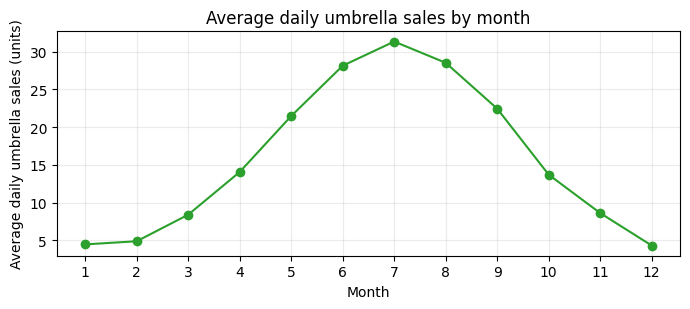

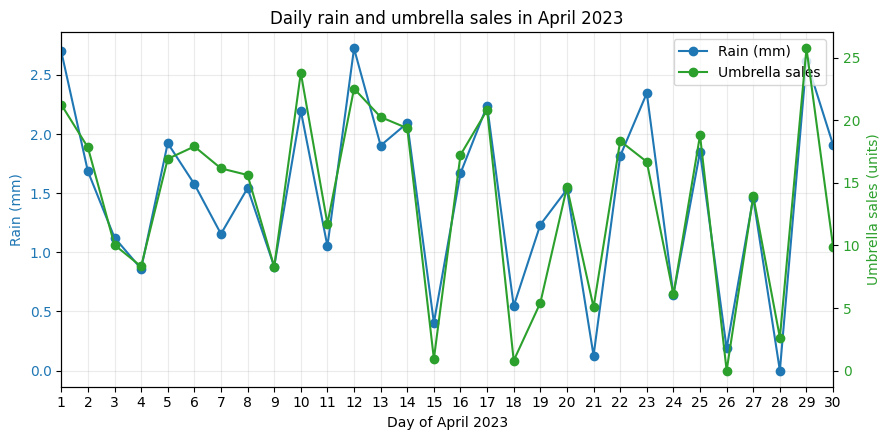

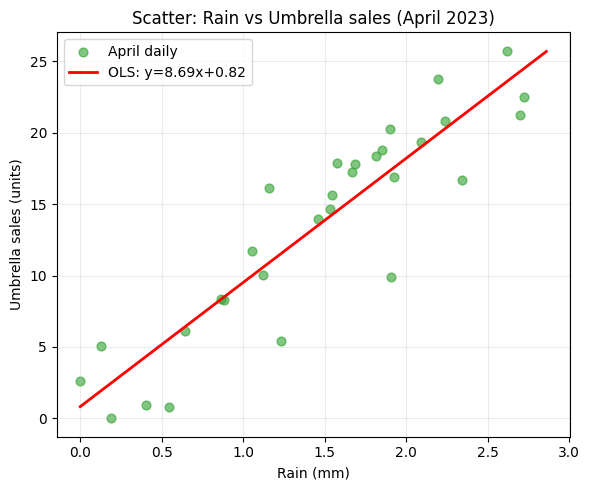

Pearson correlation (rain, umbrella) in April 2023: 0.909


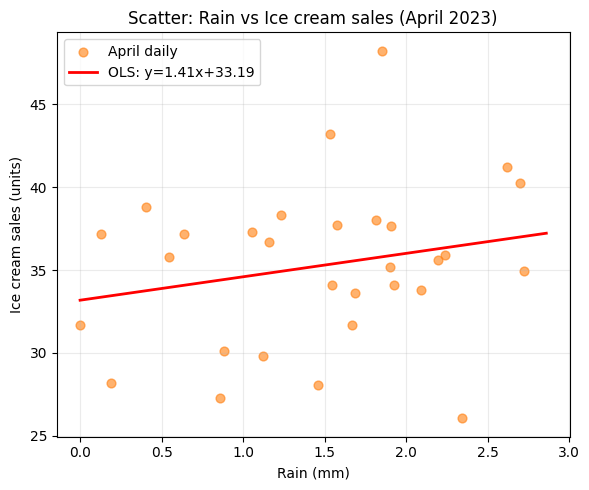

Pearson correlation (rain, ice) in April 2023: 0.223


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducible
np.random.seed(1)

# Dates: two years of daily data
dates = pd.date_range("2023-01-01", "2024-12-31", freq="D")
months = dates.month.values  # integers 1..12

# Cosine seasonal generator
def seasonal_cosine(month_array, A, B, C):
    return A + B * np.cos(2 * np.pi * (month_array - C) / 12.0)

# Parameters for rain and ice (same as before)
A_rain = 1.5; B_rain = 2.0; C_rain = 7.0
A_ice = 18.0;  B_ice = 30.0; C_ice = 6.0
sigma_rain = 1.0
sigma_ice = 6.0

# Build daily rain and ice by using the monthly mean from the cosine and adding noise
monthly_mean_rain = seasonal_cosine(months, A_rain, B_rain, C_rain)
monthly_mean_ice  = seasonal_cosine(months, A_ice,  B_ice,  C_ice)

rain_daily = np.random.normal(loc=monthly_mean_rain, scale=sigma_rain)
rain_daily = np.clip(rain_daily, a_min=0.0, a_max=None)

ice_daily = np.random.normal(loc=monthly_mean_ice, scale=sigma_ice)
ice_daily += 0.8 * rain_daily
ice_daily = np.clip(ice_daily, a_min=0.0, a_max=None)

# Umbrella sales: driven strongly by same-day rain plus additional noise
# Model: umbrella = alpha + beta * rain + extra_noise (extra_noise has its own sigma)
alpha_umb = 2.0       # baseline umbrella sales even when no rain (some incidental buys)
beta_umb = 8.0        # units per mm of rain (strong same-day response)
sigma_umb_extra = 3.0 # extra variability in umbrella sales beyond rain-driven part

# Generate umbrella daily
umb_daily = alpha_umb + beta_umb * rain_daily + np.random.normal(loc=0.0, scale=sigma_umb_extra, size=len(dates))
umb_daily = np.clip(umb_daily, a_min=0.0, a_max=None)

# Assemble DataFrame
df = pd.DataFrame({
    "date": dates,
    "month": months,
    "rain_mm": rain_daily,
    "ice_sales": ice_daily,
    "umbrella_sales": umb_daily
})
df.set_index("date", inplace=True)

# 1) Show umbrella sales monthly (average daily umbrella sales by month)
monthly_umb = df.groupby("month")["umbrella_sales"].mean()

plt.figure(figsize=(7, 3.2))
plt.plot(monthly_umb.index, monthly_umb.values, marker="o", color="tab:green")
plt.xlabel("Month")
plt.ylabel("Average daily umbrella sales (units)")
plt.title("Average daily umbrella sales by month")
plt.xticks(range(1, 13))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Select April 2023
year = 2023
month_to_plot = 4
mask_april = (df.index.year == year) & (df.index.month == month_to_plot)
df_april = df.loc[mask_april]

# 2) Plot umbrella sales and rainfall every day in April 2023 on the same graph (two y-axes)
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(df_april.index.day, df_april["rain_mm"], marker="o", color="tab:blue", label="Rain (mm)")
ax1.set_xlabel(f"Day of April {year}")
ax1.set_ylabel("Rain (mm)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(df_april.index.day)
ax1.set_xlim(1, df_april.index.day.max())

ax2 = ax1.twinx()
ax2.plot(df_april.index.day, df_april["umbrella_sales"], marker="o", color="tab:green", label="Umbrella sales")
ax2.set_ylabel("Umbrella sales (units)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title(f"Daily rain and umbrella sales in April {year}")
ax1.grid(alpha=0.25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

# Helper: simple OLS fit (slope, intercept) using closed-form on (x, y)
def ols_line(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    cov_xy = np.mean((x - x_mean) * (y - y_mean))
    var_x = np.mean((x - x_mean) ** 2)
    slope = cov_xy / var_x if var_x > 0 else 0.0
    intercept = y_mean - slope * x_mean
    return slope, intercept

# 3) Scatterplot: rainfall vs umbrella sales in April with OLS regression line
x_umb = df_april["rain_mm"].values
y_umb = df_april["umbrella_sales"].values
slope_umb, intercept_umb = ols_line(x_umb, y_umb)
x_line = np.linspace(0, x_umb.max() * 1.05, 200)
y_line_umb = intercept_umb + slope_umb * x_line

plt.figure(figsize=(6, 5))
plt.scatter(x_umb, y_umb, alpha=0.6, s=40, color="tab:green", label="April daily")
plt.plot(x_line, y_line_umb, color="red", lw=2, label=f"OLS: y={slope_umb:.2f}x+{intercept_umb:.2f}")
plt.xlabel("Rain (mm)")
plt.ylabel("Umbrella sales (units)")
plt.title(f"Scatter: Rain vs Umbrella sales (April {year})")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

R_umb = np.corrcoef(x_umb, y_umb)[0, 1]
print(f"Pearson correlation (rain, umbrella) in April {year}: {R_umb:.3f}")

# 4) Scatterplot: rainfall vs ice-cream sales in April with OLS regression line
x_ice = df_april["rain_mm"].values
y_ice = df_april["ice_sales"].values
slope_ice, intercept_ice = ols_line(x_ice, y_ice)
y_line_ice = intercept_ice + slope_ice * x_line

plt.figure(figsize=(6, 5))
plt.scatter(x_ice, y_ice, alpha=0.6, s=40, color="tab:orange", label="April daily")
plt.plot(x_line, y_line_ice, color="red", lw=2, label=f"OLS: y={slope_ice:.2f}x+{intercept_ice:.2f}")
plt.xlabel("Rain (mm)")
plt.ylabel("Ice cream sales (units)")
plt.title(f"Scatter: Rain vs Ice cream sales (April {year})")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

R_ice = np.corrcoef(x_ice, y_ice)[0, 1]
print(f"Pearson correlation (rain, ice) in April {year}: {R_ice:.3f}")